In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as ticker

from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/Mate

events = pd.read_csv("events.csv")
countries = pd.read_csv("countries.csv")
products = pd.read_csv("products.csv")

events_df = pd.DataFrame(events)
events_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Mate


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
countries_df = pd.DataFrame(countries)
countries_df.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
products_df = pd.DataFrame(products)
products_df.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
print(events_df.shape)

(1330, 10)


In [ ]:
print(countries_df.shape)

(249, 5)


In [ ]:
print(products_df.shape)

(12, 2)


In [ ]:
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
countries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
events_df.describe()

,Order ID,Product ID,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330.000000,1328.000000,1330.000000,1330.000000
mean,5.412048e+08,5788.096241,4952.201807,264.893541,187.246812
std,2.573882e+08,2820.728878,2905.198996,217.323460,176.158873
min,1.006406e+08,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,3127.000000,2356.750000,81.730000,35.840000
50%,5.387164e+08,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,8969.000000,9999.000000,668.270000,524.960000


In [ ]:
events_df["Order Priority"].unique()

array(['M', 'C', 'L', 'H', ' C', 'M '], dtype=object)

In [ ]:
events_df["Order Priority"] = (
    events_df["Order Priority"]
    .str.upper()
    .str.strip()
)
events_df["Sales Channel"] = events_df["Sales Channel"].str.capitalize()

In [ ]:
countries_df.describe()

,name,alpha-2,alpha-3,region,sub-region
count,249,248,249,248,248
unique,249,248,249,5,17
top,Afghanistan,AF,AFG,Africa,Sub-Saharan Africa
freq,1,1,1,60,53


In [ ]:
products_df["item_type"].value_counts()

,count
item_type,
Cereal,1
Household,1
Clothes,1
Beverages,1
Office Supplies,1
Fruits,1
Vegetables,1
Baby Food,1
Meat,1




*   In the events table, we have information about orders and sales. In the countries table, we have country codes, countries, regions, and sub-regions. In the products table, we have product IDs and product names.





*   The events and countries tables are linked by the Country Code and alpha-3 fields. The events and products tables are linked by the Product ID and id fields.



In [ ]:
events_df.isnull().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,82
Product ID,0
Sales Channel,0
Units Sold,2
Unit Price,0
Unit Cost,0


In [ ]:
products_df.isnull().sum()

,0
id,0
item_type,0


In [ ]:
events_df.isna().mean() / events_df.shape[0] * 100

,0
Order ID,0.000000
Order Date,0.000000
Ship Date,0.000000
Order Priority,0.000000
Country Code,0.004636
Product ID,0.000000
Sales Channel,0.000000
Units Sold,0.000113
Unit Price,0.000000
Unit Cost,0.000000


In [ ]:
clean_events = events_df.dropna(subset=["Units Sold"]).copy()
clean_events["Country Code"] = clean_events["Country Code"].fillna("Unknown")

Missing values in one of the categorical columns account for a significant share of the dataset (82 rows), therefore removing them would lead to unnecessary data loss and biased results.

Instead, these missing values were replaced with "Unknown" to preserve the data and explicitly mark incomplete records.

For the Units Sold column, missing values were removed, as this metric is essential for sales analysis and records without it cannot be meaningfully interpreted.

In [ ]:
clean_events.describe()

,Order ID,Product ID,Units Sold,Unit Price,Unit Cost
count,1.328000e+03,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,5787.775602,4952.201807,264.913245,187.211521
std,2.573496e+08,2820.635702,2905.198996,217.386320,176.187801
min,1.006406e+08,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,8969.000000,9999.000000,668.270000,524.960000


In [ ]:
countries_df.isnull().sum()

,0
name,0
alpha-2,1
alpha-3,0
region,1
sub-region,1


In [ ]:
countries_df[countries_df.isnull().any(axis=1)]

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


In [ ]:
clean_events = clean_events.copy()

clean_events["Order Date"] = pd.to_datetime(clean_events["Order Date"], errors="coerce")
clean_events["Ship Date"] = pd.to_datetime(clean_events["Ship Date"], errors="coerce")

In [ ]:
clean_events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   float64       
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 114.1+ KB


In [ ]:
print(clean_events.duplicated().sum())
print(countries_df.duplicated().sum())
print(products_df.duplicated().sum())

0
0
0


In [ ]:
df = clean_events.merge(
    countries_df,
    left_on="Country Code",
    right_on="alpha-3",
    how="inner"
)
df = df.merge(
    products,
    left_on="Product ID",
    right_on="id",
    how="inner"
)


In [ ]:
df.drop(columns=["alpha-3", "id"], inplace=True)
df.rename(columns={
    "name": "Country",
    "item_type": "Category",
    "region": "Region",
    "sub-region": "Sub-region"
}, inplace=True)
df

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,Country,alpha-2,Region,Sub-region,Category
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Norway,NO,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Serbia,RS,Europe,Southern Europe,Cereal
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Montenegro,ME,Europe,Southern Europe,Clothes
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Serbia,RS,Europe,Southern Europe,Beverages
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,Slovakia,SK,Europe,Eastern Europe,Office Supplies
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,994504153,2017-01-10,2017-01-13,M,SWE,4594,Online,4734.0,9.33,6.92,Sweden,SE,Europe,Northern Europe,Fruits
1242,994978797,2014-12-05,2015-01-02,H,ITA,1270,Offline,5192.0,47.45,31.79,Italy,IT,Europe,Southern Europe,Beverages
1243,996754205,2010-09-20,2010-09-22,L,RUS,7331,Offline,574.0,255.28,159.42,Russia,RU,Europe,Eastern Europe,Baby Food
1244,998043382,2010-06-15,2010-07-03,H,MLT,8293,Online,2070.0,437.20,263.33,Malta,MT,Europe,Southern Europe,Cosmetics


In [ ]:
total_orders = df["Order ID"].nunique()

df["Revenue"] = df["Units Sold"] * df["Unit Price"]
df["Cost"] = df["Units Sold"] * df["Unit Cost"]
df["Profit"] = df["Revenue"] - df["Cost"]

total_revenue = df["Revenue"].sum()
total_cost = df["Cost"].sum()
total_profit = df["Profit"].sum()
total_units_sold = df["Units Sold"].sum()
num_of_countries = df["Country"].nunique()

print("Total Orders:", total_orders)
print("Total Revenue:", total_revenue)
print("Total Cost:", total_cost)
print("Total Profit:", total_profit)
print("Total Units Sold:", total_units_sold)
print("Number of Countries:", num_of_countries)

df

Total Orders: 1246
Total Revenue: 1598983761.26
Total Cost: 1125274726.1999998
Total Profit: 473709035.06
Total Units Sold: 6171671.0
Number of Countries: 45


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,Country,alpha-2,Region,Sub-region,Category,Revenue,Cost,Profit
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Norway,NO,Europe,Northern Europe,Cereal,133705.00,76121.50,57583.50
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Serbia,RS,Europe,Southern Europe,Cereal,409960.10,233400.23,176559.87
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Montenegro,ME,Europe,Southern Europe,Clothes,127966.88,41968.64,85998.24
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Serbia,RS,Europe,Southern Europe,Beverages,362897.60,243129.92,119767.68
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,Slovakia,SK,Europe,Eastern Europe,Office Supplies,1445686.20,1165411.20,280275.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,994504153,2017-01-10,2017-01-13,M,SWE,4594,Online,4734.0,9.33,6.92,Sweden,SE,Europe,Northern Europe,Fruits,44168.22,32759.28,11408.94
1242,994978797,2014-12-05,2015-01-02,H,ITA,1270,Offline,5192.0,47.45,31.79,Italy,IT,Europe,Southern Europe,Beverages,246360.40,165053.68,81306.72
1243,996754205,2010-09-20,2010-09-22,L,RUS,7331,Offline,574.0,255.28,159.42,Russia,RU,Europe,Eastern Europe,Baby Food,146530.72,91507.08,55023.64
1244,998043382,2010-06-15,2010-07-03,H,MLT,8293,Online,2070.0,437.20,263.33,Malta,MT,Europe,Southern Europe,Cosmetics,905004.00,545093.10,359910.90


The company operates globally and maintains consistently high revenue and profit levels. Each order is financially significant, meaning any operational changes quickly impact overall performance.

In [ ]:
category_analysis = df.groupby("Category")[["Revenue", "Cost", "Profit", "Units Sold"]].sum().reset_index()

category_analysis

,Category,Revenue,Cost,Profit,Units Sold
0,Baby Food,1.338344e+08,8.357833e+07,50256042.90,524265.0
1,Beverages,2.742567e+07,1.837433e+07,9051339.06,577991.0
2,Cereal,9.467672e+07,5.390175e+07,40774964.94,460266.0
3,Clothes,6.330732e+07,2.076258e+07,42544746.72,579313.0
4,Cosmetics,2.213054e+08,1.332945e+08,88010907.56,506188.0
5,Fruits,4.955490e+06,3.675454e+06,1280035.35,531135.0
6,Household,2.788744e+08,2.097140e+08,69160454.84,417308.0
7,Meat,2.013398e+08,1.740421e+08,27297727.60,477233.0
8,Office Supplies,3.786662e+08,3.052543e+08,73411976.25,581481.0
9,Personal Care,4.334632e+07,3.005550e+07,13290821.60,530360.0


/tmp/ipython-input-3732525806.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


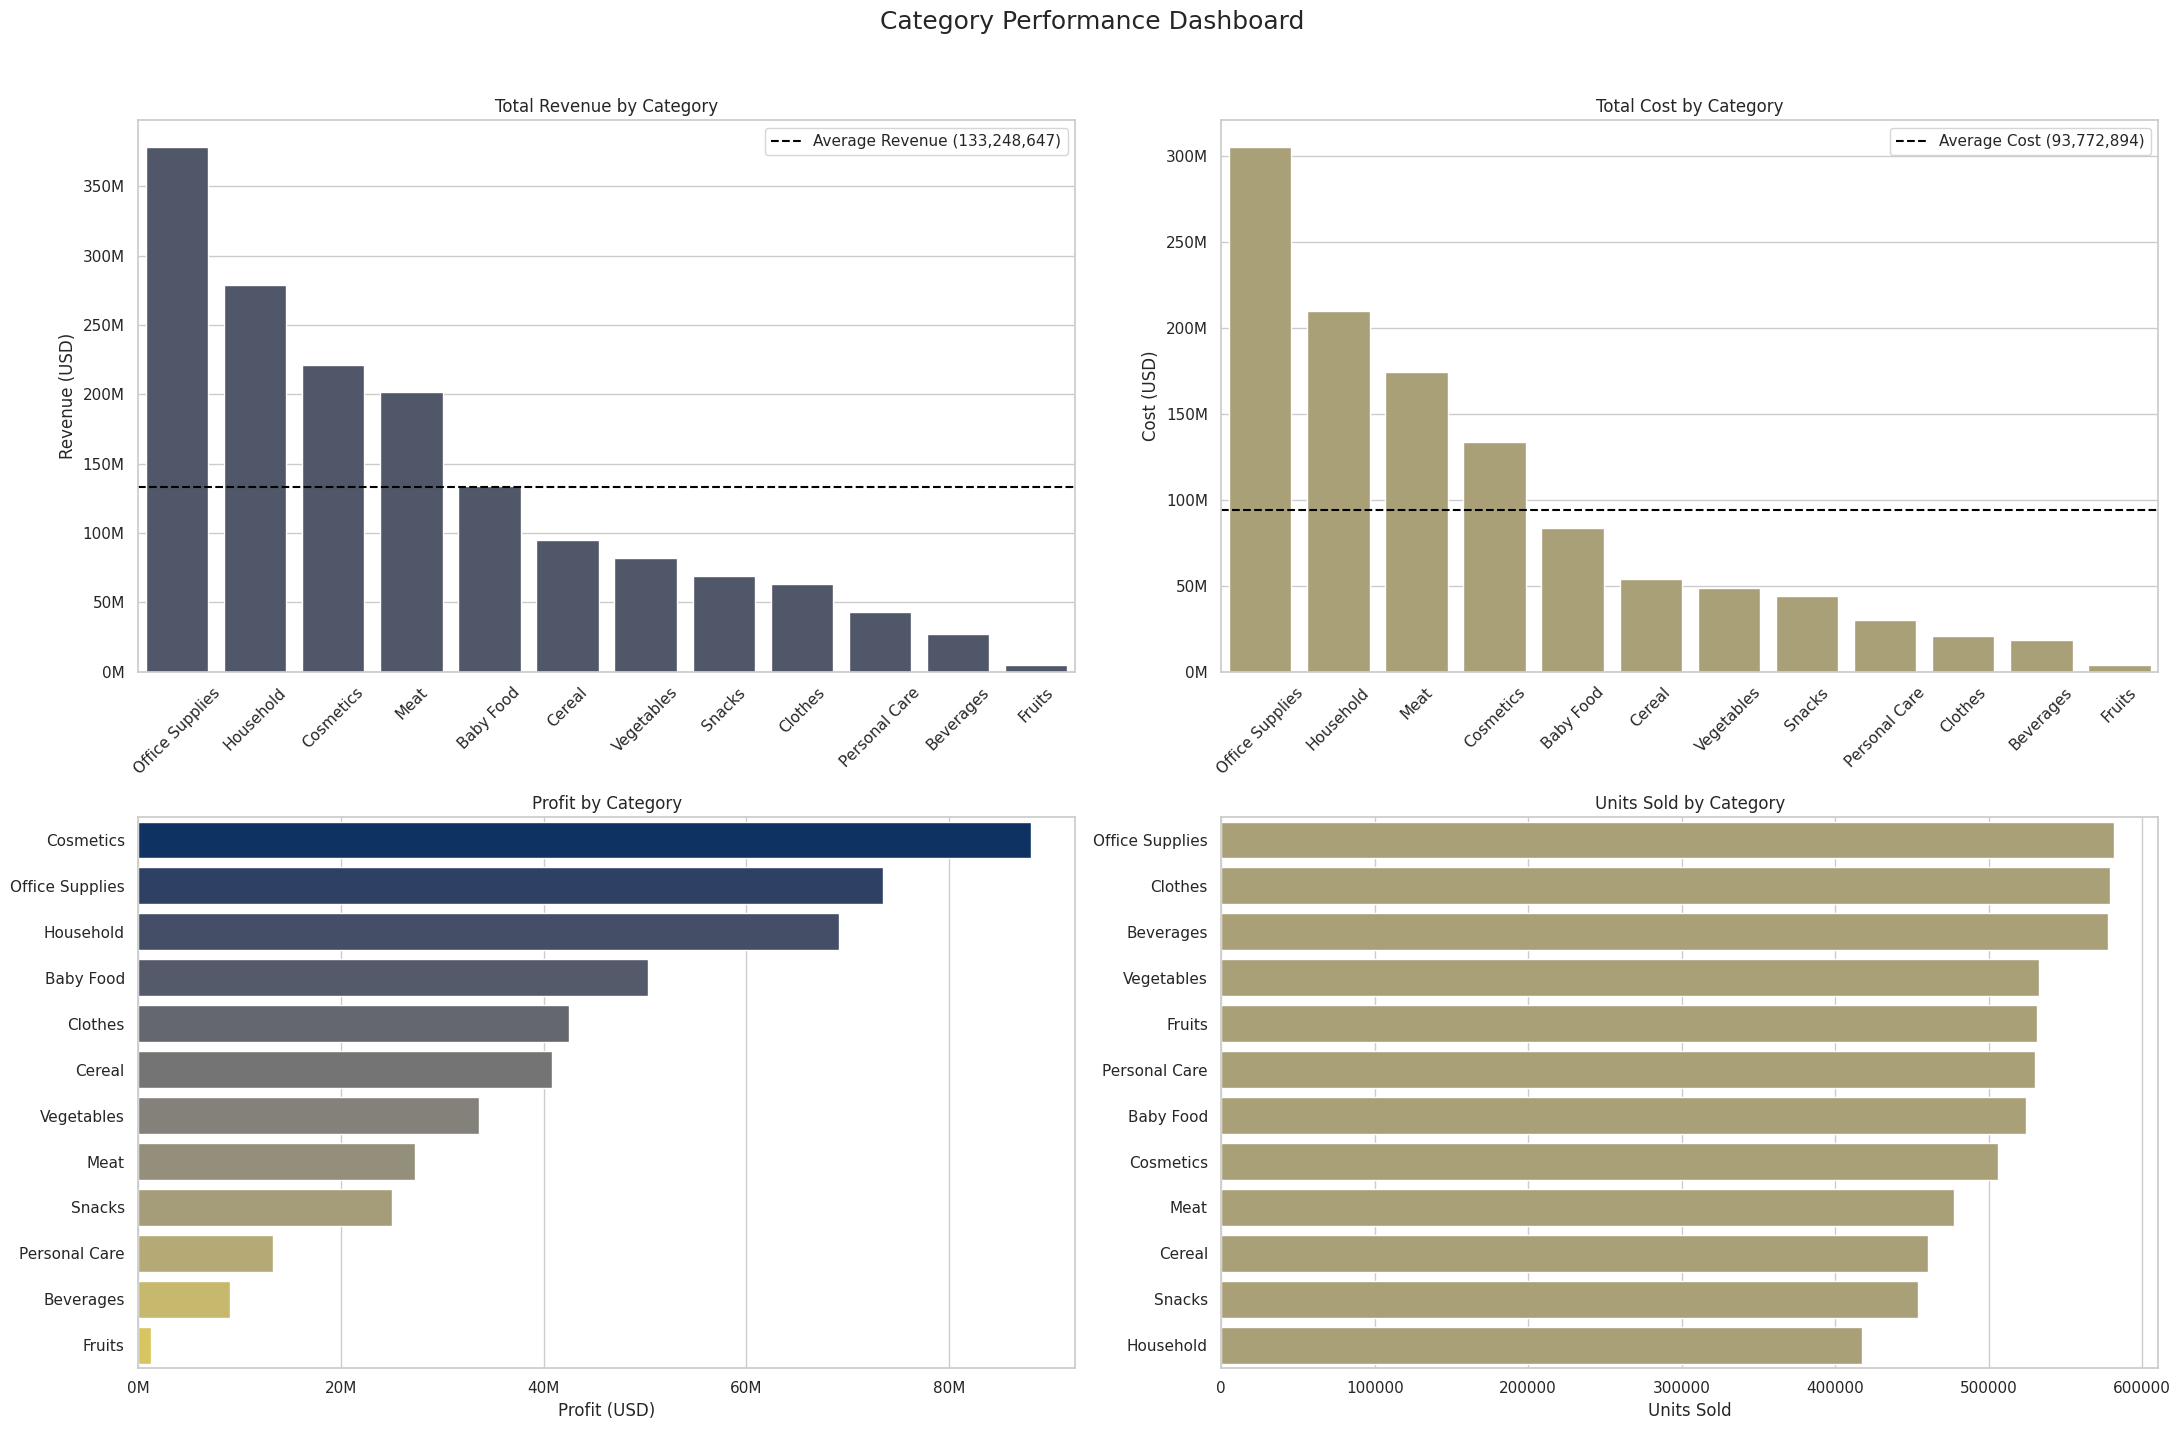

In [ ]:
sns.set(style="whitegrid")
palette = sns.color_palette("cividis")

def millions(x, pos):
    return f'{x*1e-6:.0f}M'

df_revenue = category_analysis.sort_values("Revenue", ascending=False)
df_cost = category_analysis.sort_values("Cost", ascending=False)
df_profit = category_analysis.sort_values("Profit", ascending=False)
df_units = category_analysis.sort_values("Units Sold", ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(22, 14))

sns.barplot(
    data=df_revenue,
    x="Category",
    y="Revenue",
    color=palette[1],
    ax=axes[0, 0]
)

avg_revenue = df_revenue["Revenue"].mean()
axes[0, 0].axhline(
    avg_revenue,
    linestyle="--",
    color="black",
    label=f"Average Revenue ({avg_revenue:,.0f})"
)

axes[0, 0].set_title("Total Revenue by Category")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Revenue (USD)")
axes[0, 0].yaxis.set_major_formatter(FuncFormatter(millions))
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].legend()


sns.barplot(
    data=df_cost,
    x="Category",
    y="Cost",
    color=palette[4],
    ax=axes[0, 1]
)

avg_cost = df_cost["Cost"].mean()
axes[0, 1].axhline(
    avg_cost,
    linestyle="--",
    color="black",
    label=f"Average Cost ({avg_cost:,.0f})"
)

axes[0, 1].set_title("Total Cost by Category")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Cost (USD)")
axes[0, 1].yaxis.set_major_formatter(FuncFormatter(millions))
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].legend()

sns.barplot(
    data=df_profit,
    x="Profit",
    y="Category",
    palette="cividis",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Profit by Category")
axes[1, 0].set_xlabel("Profit (USD)")
axes[1, 0].set_ylabel("")
axes[1, 0].xaxis.set_major_formatter(FuncFormatter(millions))

sns.barplot(
    data=df_units,
    x="Units Sold",
    y="Category",
    color=palette[4],
    ax=axes[1, 1]
)

axes[1, 1].set_title("Units Sold by Category")
axes[1, 1].set_xlabel("Units Sold")
axes[1, 1].set_ylabel("")


plt.suptitle("Category Performance Dashboard", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()




*   Cosmetics is the most efficient category: high profit with relatively low costs and without relying on large sales volumes. This is the strongest candidate for scaling.

*   Office Supplies and Household generate high profit mainly through volume, but their costs are also very high, which limits efficiency.



*  Meat shows poor efficiency: high revenue is offset by high costs, resulting in weak profitability.
*   Fruits, Beverages, and Snacks sell in large quantities but contribute little profit, acting more as volume drivers than profit generators.



*   Clothes has strong sales volume but only average profit, suggesting pricing or cost structure issues.











In [ ]:
geo_analysis_country = df.groupby("Country")[["Revenue", "Cost", "Profit", "Units Sold"]].sum().reset_index()
geo_analysis_country

,Country,Revenue,Cost,Profit,Units Sold
0,Albania,32224853.87,21734147.85,10490706.02,90608.0
1,Andorra,47756693.17,32346656.54,15410036.63,185686.0
2,Armenia,37519840.21,28097487.03,9422353.18,150665.0
3,Austria,35740871.49,25713361.85,10027509.64,145573.0
4,Belarus,34236260.77,22383839.72,11852421.05,153432.0
5,Belgium,25852572.30,18376512.16,7476060.14,120506.0
6,Bosnia and Herzegovina,50117508.49,36859905.72,13257602.77,153545.0
7,Bulgaria,38161555.70,27753213.09,10408342.61,150088.0
8,Croatia,27119188.24,19800958.79,7318229.45,73945.0
9,Cyprus,33008851.50,22976630.94,10032220.56,158743.0


/tmp/ipython-input-938845852.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


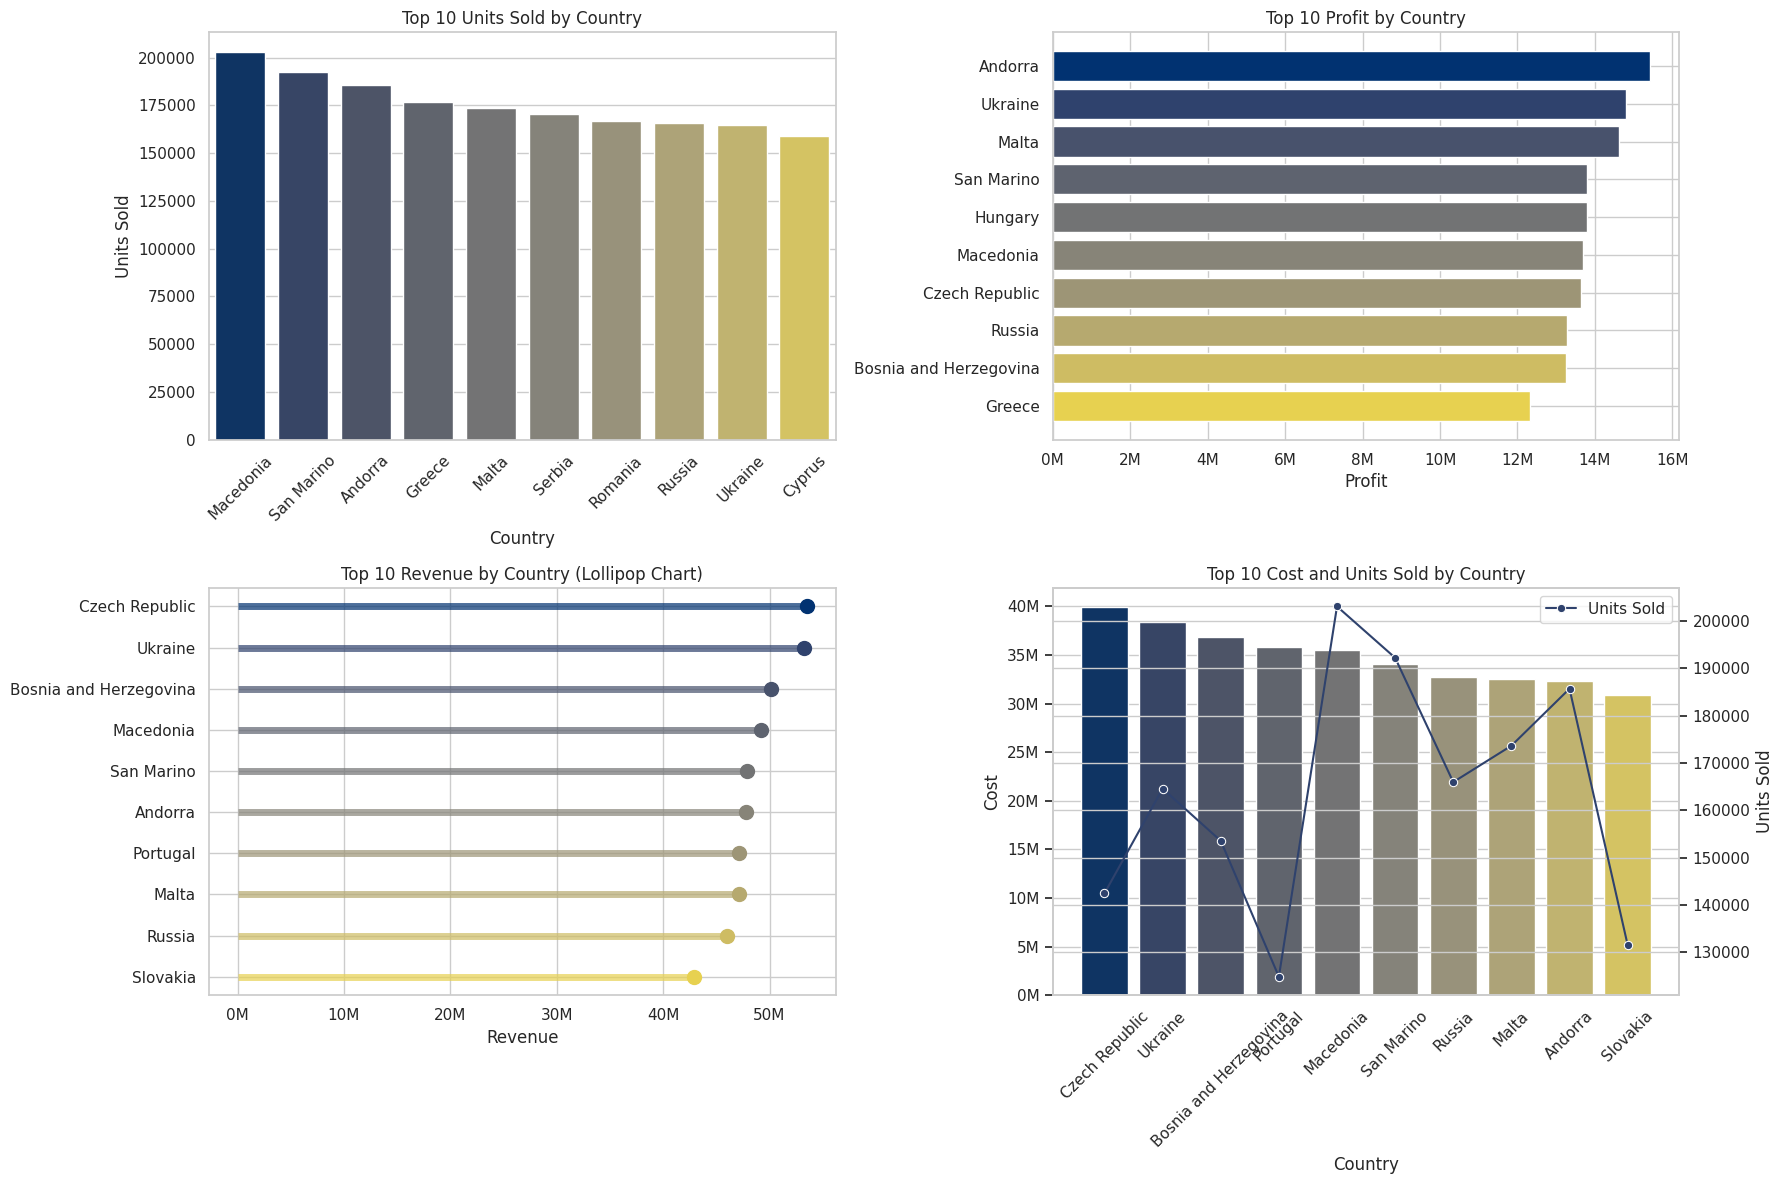

In [ ]:
sns.set_theme(style="whitegrid")
palette = sns.color_palette("cividis", n_colors=10)

def millions(x, pos):
    return f'{x*1e-6:.0f}M'

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

top10_units_sold = geo_analysis_country.sort_values("Units Sold", ascending=False).head(10)
sns.barplot(
    data=top10_units_sold,
    x="Country",
    y="Units Sold",
    hue="Country",
    legend=False,
    palette=palette,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Top 10 Units Sold by Country", fontsize=12)
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].set_ylabel("Units Sold")

top10_profit = geo_analysis_country.sort_values("Profit", ascending=False).head(10)
axes[0, 1].barh(
    top10_profit["Country"],
    top10_profit["Profit"],
    color=palette[:len(top10_profit)]
)
axes[0, 1].invert_yaxis()
axes[0, 1].set_title("Top 10 Profit by Country", fontsize=12)
axes[0, 1].set_xlabel("Profit")
axes[0, 1].xaxis.set_major_formatter(ticker.FuncFormatter(millions))

top10_revenue = geo_analysis_country.sort_values("Revenue", ascending=False).head(10)
ax = axes[1, 0]

for i, (country, revenue) in enumerate(zip(top10_revenue["Country"], top10_revenue["Revenue"])):
    ax.hlines(y=i, xmin=0, xmax=revenue, color=palette[i], alpha=0.7, linewidth=5)
    ax.plot(revenue, i, "o", color=palette[i], markersize=10)

ax.set_yticks(range(len(top10_revenue)))
ax.set_yticklabels(top10_revenue["Country"])
ax.invert_yaxis()
ax.set_xlabel("Revenue")
ax.set_title("Top 10 Revenue by Country")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(millions))

top10_cost = geo_analysis_country.sort_values("Cost", ascending=False).head(10)
ax1 = axes[1, 1]
sns.barplot(
    data=top10_cost,
    x="Country",
    y="Cost",
    ax=ax1,
    palette=palette[:len(top10_cost)]
)
ax1.set_ylabel("Cost")
ax1.tick_params(axis="x", rotation=45)
ax1.set_title("Top 10 Cost and Units Sold by Country", fontsize=12)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(millions))

ax2 = ax1.twinx()
sns.lineplot(
    data=top10_cost,
    x="Country",
    y="Units Sold",
    marker="o",
    ax=ax2,
    color=palette[1],
    label="Units Sold"
)
ax2.set_ylabel("Units Sold")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


*  Andorra and San Marino are key markets both in terms of sales volume and profitability. They can serve as examples for other countries.

*   Ukraine is a profitable market with high costs, requiring attention to operational optimization.


*   Greece and Malta are stable markets with a balance between revenue, costs, and sales volume.
*   Countries with low sales volume (e.g., Slovakia, Bosnia) need further analysis to determine the reasons for low activity.




In [ ]:
geo_analysis_region = df.groupby("Region")[["Revenue", "Cost", "Profit", "Units Sold"]].sum().reset_index()
geo_analysis_region

,Region,Revenue,Cost,Profit,Units Sold
0,Asia,9.333089e+07,6.817863e+07,2.515225e+07,410427.0
1,Europe,1.505653e+09,1.057096e+09,4.485568e+08,5761244.0


/tmp/ipython-input-3054036604.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo_analysis_region, x="Region", y="Revenue", ax=axes[0,0], palette=palette)


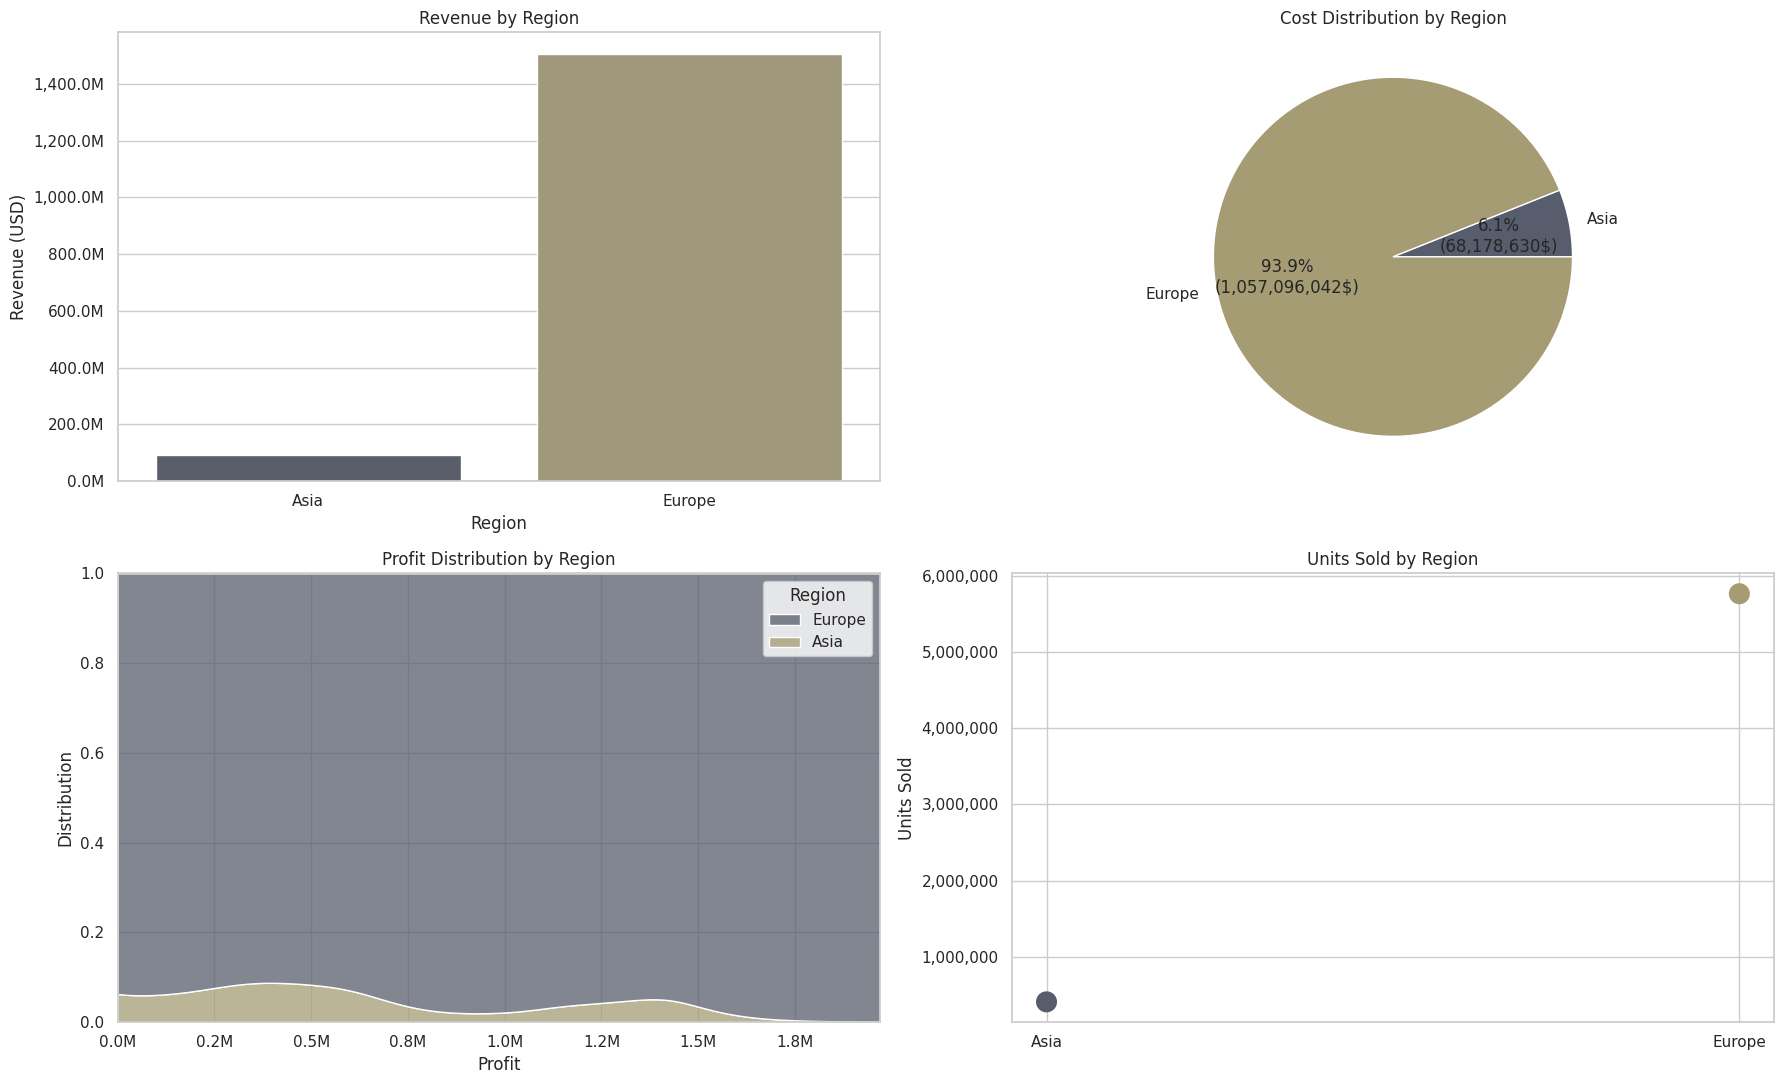

In [ ]:
def millions(x, pos):
    return f'{x*1e-6:,.1f}M'

sns.set_theme(style="whitegrid")
palette = sns.color_palette("cividis", n_colors=len(geo_analysis_region))

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

sns.barplot(data=geo_analysis_region, x="Region", y="Revenue", ax=axes[0,0], palette=palette)
axes[0,0].set_title("Revenue by Region")
axes[0,0].set_ylabel("Revenue (USD)")
axes[0,0].yaxis.set_major_formatter(FuncFormatter(millions))

axes[0,1].pie(geo_analysis_region["Cost"], labels=geo_analysis_region["Region"],
               autopct=lambda p: f'{p:.1f}%\n({p/100*geo_analysis_region["Cost"].sum():,.0f}$)',
               colors=palette)
axes[0,1].set_title("Cost Distribution by Region")

sns.kdeplot(
    data=df,
    x="Profit",
    hue="Region",
    multiple="fill",
    clip=(0, None),
    palette=palette,
    ax=axes[1,0]
)
axes[1,0].set_title("Profit Distribution by Region")
axes[1,0].set_ylabel("Distribution")
axes[1,0].xaxis.set_major_formatter(FuncFormatter(millions))

axes[1,1].scatter(geo_analysis_region["Region"], geo_analysis_region["Units Sold"], s=200, c=palette)
axes[1,1].set_title("Units Sold by Region")
axes[1,1].set_ylabel("Units Sold")
axes[1,1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()





*   Europe — the key market: high revenue, large costs, significant profit, and high sales volumes. The business here is large-scale and efficient.
*   Asia — currently a smaller market: limited revenue and profit, low sales volumes. There are opportunities for growth, but the scale is still small.




In [ ]:
sales_channel_analysis = df.groupby("Sales Channel")[["Revenue", "Cost", "Profit", "Units Sold"]].sum().reset_index()
sales_channel_analysis

,Sales Channel,Revenue,Cost,Profit,Units Sold
0,Offline,8.100305e+08,5.715191e+08,2.385113e+08,3113412.0
1,Online,7.889533e+08,5.537556e+08,2.351977e+08,3058259.0


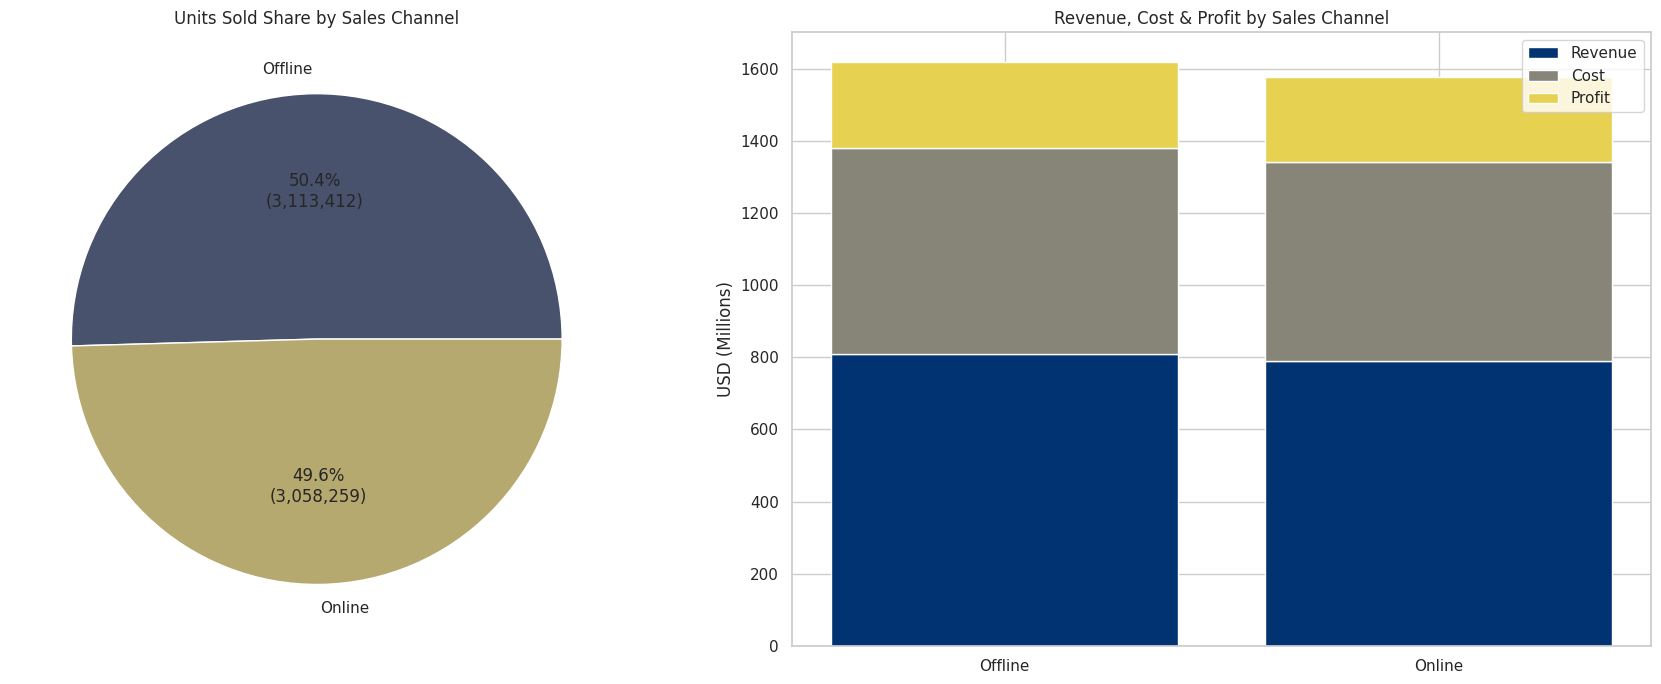

In [ ]:
def millions(x, pos):
    return f'{x*1e-6:,.1f}M'

sns.set_theme(style="whitegrid")
palette = sns.color_palette("cividis", n_colors=10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].pie(
    sales_channel_analysis["Units Sold"],
    labels=sales_channel_analysis["Sales Channel"],
    autopct=lambda p: f'{p:.1f}%\n({p/100*sales_channel_analysis["Units Sold"].sum():,.0f})',
    colors=[palette[2], palette[7]]
)
axes[0].set_title("Units Sold Share by Sales Channel")

axes[1].bar(
    sales_channel_analysis["Sales Channel"],
    sales_channel_analysis["Revenue"] * 1e-6,
    color=palette[0],
    label="Revenue"
)
axes[1].bar(
    sales_channel_analysis["Sales Channel"],
    sales_channel_analysis["Cost"] * 1e-6,
    bottom=sales_channel_analysis["Revenue"] * 1e-6,
    color=palette[5],
    label="Cost"
)
axes[1].bar(
    sales_channel_analysis["Sales Channel"],
    sales_channel_analysis["Profit"] * 1e-6,
    bottom=(sales_channel_analysis["Revenue"] + sales_channel_analysis["Cost"]) * 1e-6,
    color=palette[9],
    label="Profit"
)

axes[1].set_title("Revenue, Cost & Profit by Sales Channel")
axes[1].set_ylabel("USD (Millions)")
axes[1].legend()

plt.tight_layout()
plt.show()


Both channels contribute significantly. The business should support them in parallel rather than focusing on a single channel.


In [ ]:
df["Delivery Days"] = (
    pd.to_datetime(df["Ship Date"])
    - pd.to_datetime(df["Order Date"])
).dt.days
df

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,Country,alpha-2,Region,Sub-region,Category,Revenue,Cost,Profit,Delivery Days
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Norway,NO,Europe,Northern Europe,Cereal,133705.00,76121.50,57583.50,10
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Serbia,RS,Europe,Southern Europe,Cereal,409960.10,233400.23,176559.87,0
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Montenegro,ME,Europe,Southern Europe,Clothes,127966.88,41968.64,85998.24,31
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Serbia,RS,Europe,Southern Europe,Beverages,362897.60,243129.92,119767.68,38
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,Slovakia,SK,Europe,Eastern Europe,Office Supplies,1445686.20,1165411.20,280275.00,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,994504153,2017-01-10,2017-01-13,M,SWE,4594,Online,4734.0,9.33,6.92,Sweden,SE,Europe,Northern Europe,Fruits,44168.22,32759.28,11408.94,3
1242,994978797,2014-12-05,2015-01-02,H,ITA,1270,Offline,5192.0,47.45,31.79,Italy,IT,Europe,Southern Europe,Beverages,246360.40,165053.68,81306.72,28
1243,996754205,2010-09-20,2010-09-22,L,RUS,7331,Offline,574.0,255.28,159.42,Russia,RU,Europe,Eastern Europe,Baby Food,146530.72,91507.08,55023.64,2
1244,998043382,2010-06-15,2010-07-03,H,MLT,8293,Online,2070.0,437.20,263.33,Malta,MT,Europe,Southern Europe,Cosmetics,905004.00,545093.10,359910.90,18


In [ ]:
df["Delivery Days"].describe()


,Delivery Days
count,1246.000000
mean,24.875602
std,14.622855
min,0.000000
25%,12.000000
50%,25.000000
75%,37.000000
max,50.000000


In [ ]:
delivery_by_category = (
    df
    .groupby("Category")["Delivery Days"]
    .agg(["mean", "min", "max", "median"])
    .reset_index()
    .sort_values("median")
)
delivery_by_category.columns = [
    "Category",
    "Avg Delivery Days",
    "Min Delivery Days",
    "Max Delivery Days",
    "Median Delivery Days"
]

profit_by_category = df.groupby("Category")["Profit"].sum().reset_index()
profit_by_category.columns = ["Category", "Total Profit"]

delivery_by_category = delivery_by_category.merge(profit_by_category, on="Category")

delivery_by_category

,Category,Avg Delivery Days,Min Delivery Days,Max Delivery Days,Median Delivery Days,Total Profit
0,Personal Care,20.444444,0,50,20.0,13290821.60
1,Clothes,23.539216,0,50,21.0,42544746.72
2,Fruits,24.475728,1,50,23.0,1280035.35
3,Beverages,23.946903,0,50,23.0,9051339.06
4,Vegetables,24.438095,0,50,23.0,33617356.30
5,Household,23.571429,0,50,24.0,69160454.84
6,Meat,25.735294,0,50,24.5,27297727.60
7,Snacks,25.263158,0,49,25.0,25012661.94
8,Cosmetics,25.879630,0,50,28.0,88010907.56
9,Office Supplies,27.283186,1,50,28.0,73411976.25


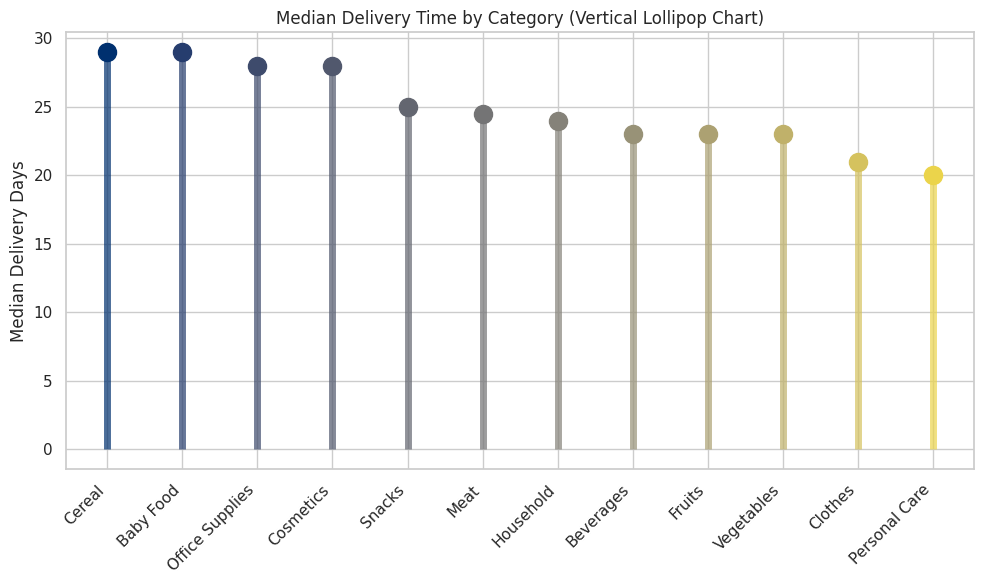

In [ ]:
sns.set_theme(style="whitegrid")
palette = sns.color_palette("cividis", n_colors=len(delivery_by_category))

# Вертикальний лоліпоп
plt.figure(figsize=(10,6))
ax = plt.gca()

# Сортуємо категорії за Median Delivery Days
delivery_sorted = delivery_by_category.sort_values("Median Delivery Days", ascending=False)

for i, (category, days) in enumerate(zip(delivery_sorted["Category"], delivery_sorted["Median Delivery Days"])):
    ax.vlines(x=i, ymin=0, ymax=days, color=palette[i], alpha=0.7, linewidth=5)  # лінія
    ax.plot(i, days, "o", color=palette[i], markersize=13)  # точка

ax.set_xticks(range(len(delivery_sorted)))
ax.set_xticklabels(delivery_sorted["Category"], rotation=45, ha="right")
ax.set_ylabel("Median Delivery Days")
ax.set_title("Median Delivery Time by Category (Vertical Lollipop Chart)")

plt.tight_layout()
plt.show()

Delivery speed varies significantly by category, with Personal Care and Clothes delivered the fastest, while Cosmetics, Office Supplies, Baby Food, and Cereal take the longest. Slow delivery in high-profit categories signals clear opportunities to improve logistics and inventory planning.


In [ ]:
delivery_by_countries = (
    df
    .groupby("Country")["Delivery Days"]
    .agg(["mean", "min", "max", "median"])
    .reset_index()
    .sort_values("median", ascending=False)
)
delivery_by_countries.columns = [
    "Countries",
    "Avg Delivery Days",
    "Min Delivery Days",
    "Max Delivery Days",
    "Median Delivery Days"
]

profit_by_countries = df.groupby("Country")["Profit"].sum().reset_index()
profit_by_countries.columns = ["Countries", "Total Profit"]

delivery_by_countries = delivery_by_countries.merge(profit_by_countries, on="Countries")

delivery_by_countries

,Countries,Avg Delivery Days,Min Delivery Days,Max Delivery Days,Median Delivery Days,Total Profit
0,Hungary,32.640000,2,50,36.0,13786231.03
1,Russia,27.375000,0,50,34.0,13267682.64
2,Monaco,26.846154,5,48,33.0,4797048.77
3,Georgia,29.695652,7,47,32.0,5697679.21
4,Slovakia,28.466667,3,50,32.0,12052790.03
5,Finland,26.217391,5,43,31.0,7525362.83
6,Luxembourg,27.750000,0,48,30.5,9870766.11
7,Lithuania,27.560000,5,49,30.0,7997297.83
8,Bosnia and Herzegovina,26.060606,1,50,30.0,13257602.77
9,Austria,28.500000,3,50,29.0,10027509.64


Text(0, 0.5, '')

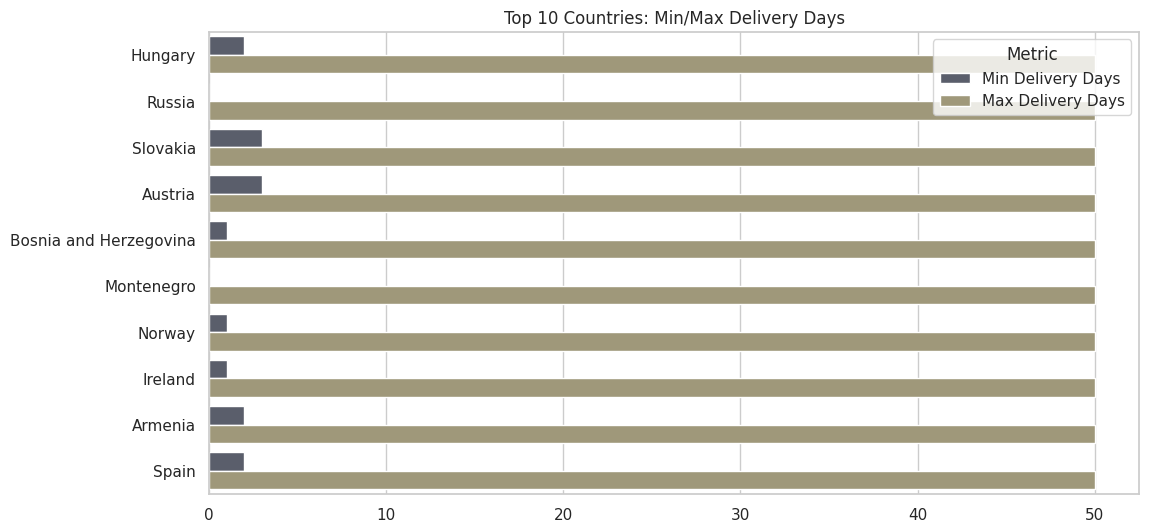

In [ ]:
top10_countries = (
    delivery_by_countries.sort_values("Max Delivery Days", ascending=False)
    .head(10)
)

delivery_melted = top10_countries.melt(
    id_vars="Countries",
    value_vars=["Min Delivery Days", "Max Delivery Days"],
    var_name="Metric",
    value_name="Days"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=delivery_melted,
    y="Countries",
    x="Days",
    hue="Metric",
    palette="cividis"
)

plt.title("Top 10 Countries: Min/Max Delivery Days")
plt.xlabel("")
plt.ylabel("")

*   Delivery times are very inconsistent between countries: some orders arrive extremely fast, others take up to 50 days.
*  Countries like Hungary and Slovakia have particularly long deliveries (up to 50 days), signaling a need to review and improve logistics in these markets.

*   Looking only at the Min and Max values, it’s easy to see differences in logistics efficiency between countries.




In [ ]:
delivery_by_regions = (
    df
    .groupby("Region")["Delivery Days"]
    .agg(["mean", "min", "max", "median"])
    .reset_index()
    .sort_values("median", ascending=False)
)
delivery_by_regions.columns = [
    "Region",
    "Avg Delivery Days",
    "Min Delivery Days",
    "Max Delivery Days",
    "Median Delivery Days"
]

profit_by_regio = df.groupby("Region")["Profit"].sum().reset_index()
profit_by_regio.columns = ["Region", "Total Profit"]

delivery_by_regions = delivery_by_regions.merge(profit_by_regio, on="Region")

delivery_by_regions

,Region,Avg Delivery Days,Min Delivery Days,Max Delivery Days,Median Delivery Days,Total Profit
0,Asia,26.085366,1,50,25.5,2.515225e+07
1,Europe,24.790378,0,50,25.0,4.485568e+08


Text(0, 0.5, '')

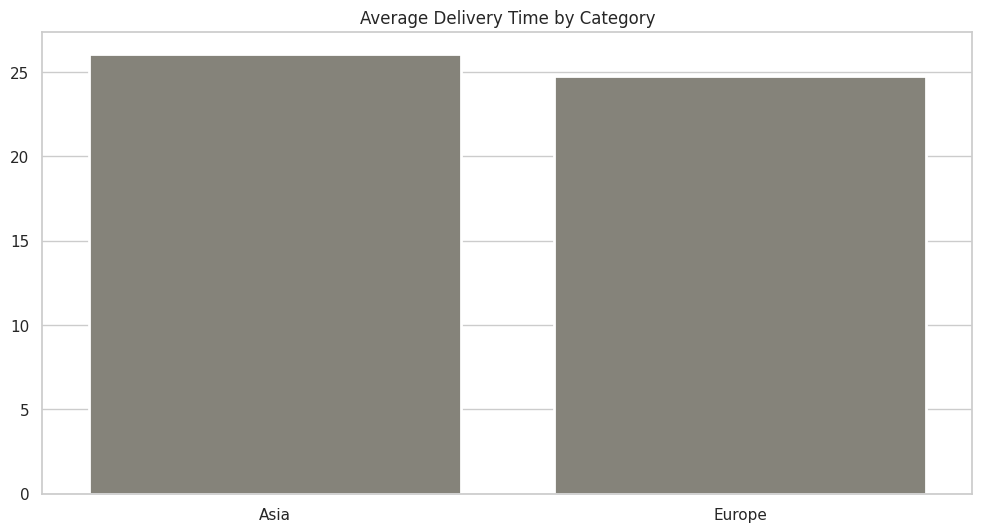

In [ ]:
plt.figure(figsize=(12,6))

palette = sns.color_palette("cividis", 10)

sns.barplot(
    data=delivery_by_regions,
    y="Avg Delivery Days",
    x="Region",
    color=palette[5],
    linewidth=2
)

plt.title("Average Delivery Time by Category")
plt.xlabel("")
plt.ylabel("")



*   On average, delivery in Europe is slightly faster than in Asia (~1.3 days difference).

*   The average is slightly inflated due to very long orders (up to 50 days in both regions).



In [ ]:
profit_by_delivery = (
    df.groupby("Delivery Days")["Profit"]
      .agg(["mean", "min", "max", "sum", "count"])
      .reset_index()
      .sort_values("Delivery Days")
)
profit_by_delivery.head()

,Delivery Days,mean,min,max,sum,count
0,0,337888.328421,15403.72,1654814.05,6419878.24,19
1,1,338390.965263,6519.05,750180.12,6429428.34,19
2,2,346590.220400,3508.96,1238302.14,8664755.51,25
3,3,285391.693226,269.92,1056781.86,8847142.49,31
4,4,278809.762593,7781.89,1089643.29,7527863.59,27


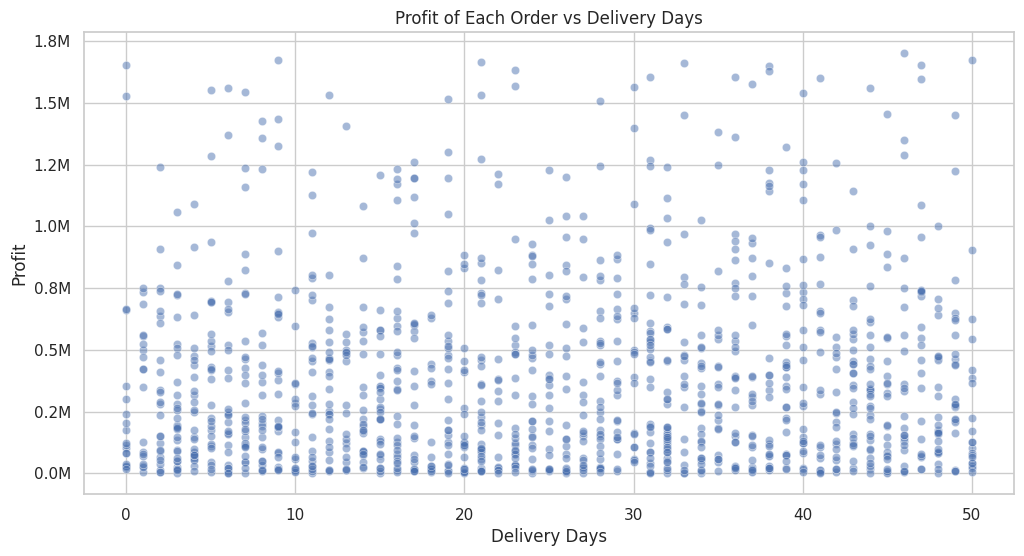

In [ ]:
def millions(x, pos):
    return f'{x*1e-6:,.1f}M'

plt.figure(figsize=(12,6))
ax = plt.gca()

sns.scatterplot(data=df, x="Delivery Days", y="Profit", alpha=0.5, ax=ax)
plt.title("Profit of Each Order vs Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Profit")

ax.yaxis.set_major_formatter(FuncFormatter(millions))

plt.show()





*   Profit doesn’t depend on how long delivery takes.
*   Fast orders don’t necessarily bring in more money, and slow orders don’t necessarily bring in less.

*   So the company can focus on improving delivery for customer convenience without worrying that it will strongly affect profit.










In [ ]:
df['Year'] = df['Order Date'].dt.year

df['Month'] = df['Order Date'].dt.month_name()
months_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
df['Month'] = pd.Categorical(df['Month'], categories=months_order)

df['Weekday'] = df['Order Date'].dt.day_name()
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df['Weekday'] = pd.Categorical(df['Weekday'], categories=days_order)

top_countries = df.groupby('Country')['Profit'].sum().sort_values(ascending=False).head(10).index
df['Top Country'] = df['Country'].where(df['Country'].isin(top_countries), 'Other')

In [ ]:
grouped_month_by_category = df.groupby(['Month', 'Category'])['Profit'].sum().reset_index()
pivot_month_by_category = grouped_month_by_category.pivot(index='Month', columns='Category', values='Profit').fillna(0)
grouped_month_by_category

/tmp/ipython-input-2403174217.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_month_by_category = df.groupby(['Month', 'Category'])['Profit'].sum().reset_index()


,Month,Category,Profit
0,January,Baby Food,7465385.08
1,January,Beverages,392189.04
2,January,Cereal,4172234.64
3,January,Clothes,6038750.88
4,January,Cosmetics,13805104.13
...,...,...,...
139,December,Meat,4001940.80
140,December,Office Supplies,7819041.25
141,December,Personal Care,1496959.10
142,December,Snacks,1293915.24


In [ ]:
pivot_month_by_category

Category,Baby Food,Beverages,Cereal,Clothes,Cosmetics,Fruits,Household,Meat,Office Supplies,Personal Care,Snacks,Vegetables
Month,,,,,,,,,,,,
January,7465385.08,392189.04,4172234.64,6038750.88,13805104.13,77669.48,3986966.61,1726010.0,5155923.75,1166618.18,3926133.42,2394268.38
February,2433022.66,1287408.60,4640521.38,870557.76,6147869.33,60691.03,7326923.30,2214440.8,5563585.00,1231348.16,1698312.00,3802130.51
March,5983677.06,711010.98,2507274.18,3819981.60,9607534.59,223353.98,6093394.91,2368251.6,8609366.25,1191477.70,2701418.88,3567223.78
April,2637683.76,786476.52,980602.71,5797794.24,3449059.19,104524.11,6107647.69,1943484.4,5301237.50,1463829.78,2280921.24,2486564.44
May,6053942.44,581189.58,2348166.54,5589518.40,6784233.53,74155.70,4699274.15,1601314.0,8756195.00,831315.38,1348779.54,3400055.54
June,5018750.30,369121.86,4466796.39,5669568.00,6985053.38,82221.97,8103534.08,2467379.2,5024245.00,1671577.18,1881707.64,2862187.94
July,2605378.94,997917.84,4808842.38,2930549.76,9650654.35,105709.83,5368491.89,2783123.2,7335377.50,1086000.16,3274764.60,2327539.97
August,4650935.48,849586.32,2522245.89,2376738.72,3050549.15,59018.49,7613801.93,2733130.4,2899583.75,360663.52,1553624.64,2735044.12
September,4842943.06,587046.42,4076734.62,3172975.20,9589278.24,115077.50,6797581.68,984698.0,4707357.50,1114317.96,1710608.22,1342080.67


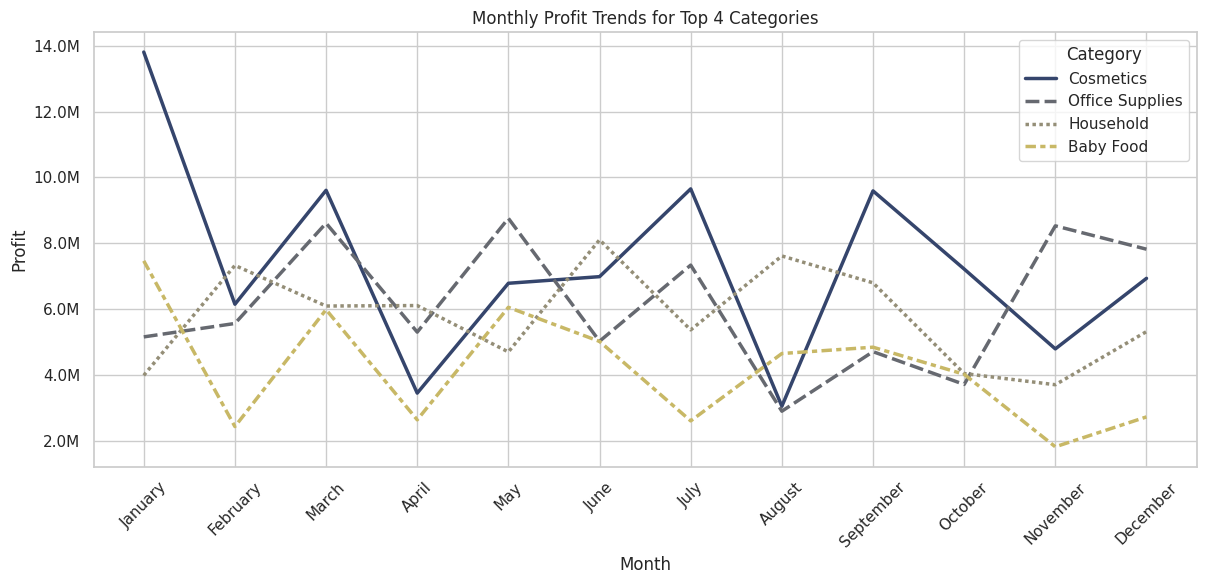

In [ ]:
def millions(x, pos):
    return f'{x*1e-6:,.1f}M'

top4_categories = (
    pivot_month_by_category.sum()
    .sort_values(ascending=False)
    .head(4)
    .index
)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))
ax = plt.gca()

sns.lineplot(
    data=pivot_month_by_category[top4_categories],
    palette="cividis",
    linewidth=2.5,
    ax=ax
)

plt.title("Monthly Profit Trends for Top 4 Categories")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.tight_layout()
ax.yaxis.set_major_formatter(FuncFormatter(millions))
plt.show()



The business experiences high monthly ups and downs in all major categories, without steady growth. Cosmetics brings in the most profit but also sees huge drops (like from January to April). In August, most categories fall at the same time, creating a serious financial risk. The fact that there’s no year-end holiday boost points to possible problems with inventory or seasonal marketing.

In [ ]:
grouped_year_by_country = df.groupby(['Year', 'Country'])['Revenue'].sum().reset_index()
pivot_year_by_country = grouped_year_by_country.pivot(index='Year', columns='Country', values='Revenue')
grouped_year_by_country

,Year,Country,Revenue
0,2010,Albania,8531301.81
1,2010,Andorra,10463527.98
2,2010,Armenia,7672185.09
3,2010,Austria,11632719.09
4,2010,Belarus,2080164.18
...,...,...,...
345,2017,Spain,5252435.91
346,2017,Sweden,3829883.02
347,2017,Switzerland,4039973.25
348,2017,Ukraine,7347212.53


In [ ]:
sorted_countries = pivot_year_by_country.sum().sort_values(ascending=False).index
pivot_sorted = pivot_year_by_country[sorted_countries]

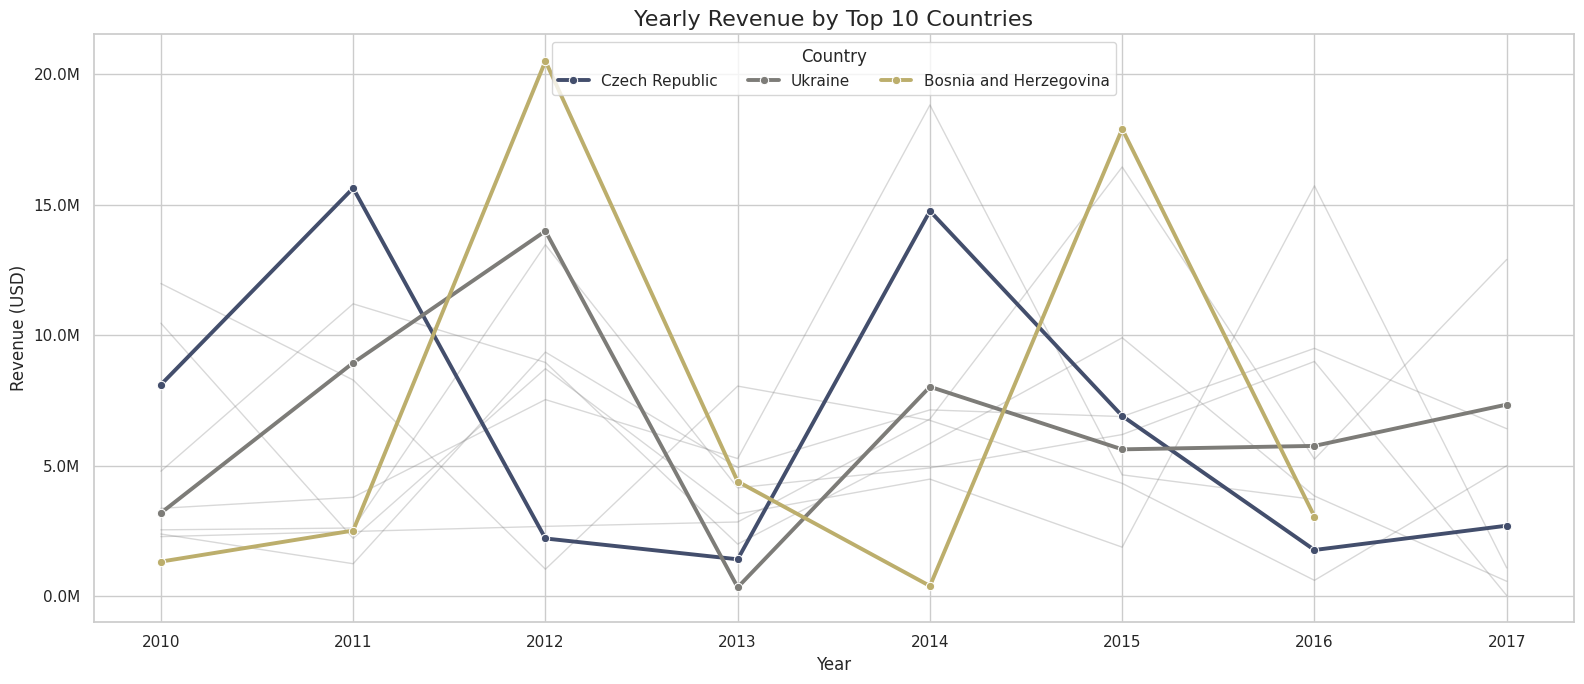

In [ ]:
top_10 = (
    pivot_year_by_country.sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

pivot_top10 = pivot_year_by_country[top_10]

top_3 = top_10[:3]
other_countries = top_10[3:]

df_long = (
    pivot_top10
    .reset_index()
    .melt(id_vars='Year', value_vars=top_10,
          var_name='Country', value_name='Revenue')
)

def millions(x, pos):
    return f'{x*1e-6:,.1f}M'

sns.set_theme(style="whitegrid")
palette = sns.color_palette("cividis", n_colors=3)

plt.figure(figsize=(16, 7))
ax = plt.gca()

for country in other_countries:
    data = df_long[df_long['Country'] == country]
    sns.lineplot(
        data=data,
        x='Year',
        y='Revenue',
        color='gray',
        alpha=0.3,
        linewidth=1,
        ax=ax,
        legend=False
    )

for i, country in enumerate(top_3):
    data = df_long[df_long['Country'] == country]
    sns.lineplot(
        data=data,
        x='Year',
        y='Revenue',
        label=country,
        color=palette[i],
        marker='o',
        linewidth=2.8,
        ax=ax
    )

plt.title('Yearly Revenue by Top 3 Countries', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(FuncFormatter(millions))
plt.legend(title='Country', loc='upper center', ncol=3)
plt.tight_layout()
plt.show()


The business operates on a “high-risk, high-reward” model, with no stable growth. Revenue mostly comes from occasional big deals rather than regular customers, so profits in key markets often drop to zero. The main priority should be to smooth out these fluctuations and build a steady, recurring revenue stream.

In [ ]:
grouped_month_by_region = df.groupby(['Month', 'Region'])['Profit'].sum().reset_index()
pivot_month_by_region = grouped_month_by_region.pivot(index='Month', columns='Region', values='Profit').fillna(0)
pivot_month_by_region

/tmp/ipython-input-816051442.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_month_by_region = df.groupby(['Month', 'Region'])['Profit'].sum().reset_index()


Region,Asia,Europe
Month,,
January,2590926.43,47716327.16
February,2738447.77,34538362.76
March,2791492.45,44592473.06
April,488870.44,32850955.14
May,2140690.46,39927449.34
June,4211288.17,40390854.77
July,1980728.07,41293622.35
August,1616179.50,29788742.91
September,2204604.64,36836094.43


In [ ]:
long_df = pivot_month_by_region.melt(var_name="Region", value_name="Profit")

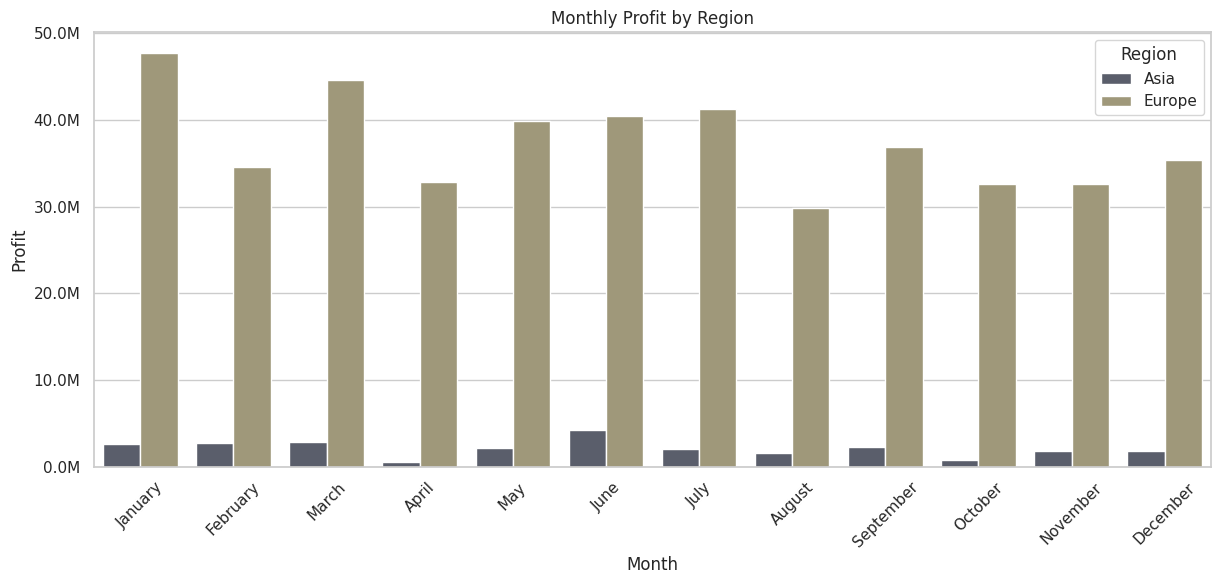

In [ ]:
pivot_long = pivot_month_by_region.reset_index().melt(
    id_vars='Month',
    var_name='Region',
    value_name='Profit'
)

def millions(x, pos):
    return f'{x*1e-6:,.1f}M'

plt.figure(figsize=(12,6))
ax = plt.gca()
sns.barplot(data=pivot_long, x='Month', y='Profit', hue='Region', palette='cividis', ax=ax)
plt.xticks(rotation=45)
plt.title("Monthly Profit by Region")
plt.ylabel("Profit")
plt.xlabel("Month")
plt.tight_layout()
ax.yaxis.set_major_formatter(FuncFormatter(millions))
plt.show()


### Europe
*   January, March, July: Highest profit levels (around 45–50 million).
*   February, April, August, October: Profit is slightly lower (around 35–40 million).
*   May, June, September, November, December: Profit fluctuates between 30–35 million.

Profit in Europe remains consistently high throughout the year, with only minor fluctuations.

### Asia
*   January, March, May, July: Profit fluctuates between 2–5 million.
*   February, April, June, August, October, November, December: Profit is around 1–3 million.

Profit in Asia is significantly lower and less stable than in Europe.


In [ ]:
grouped_weekdays = df.groupby(['Weekday', 'Category'])['Profit'].sum().reset_index()
pivot_weekdays = grouped_weekdays.pivot(index='Weekday', columns='Category', values='Profit').fillna(0)
pivot_weekdays

/tmp/ipython-input-3402243908.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_weekdays = df.groupby(['Weekday', 'Category'])['Profit'].sum().reset_index()


Category,Baby Food,Beverages,Cereal,Clothes,Cosmetics,Fruits,Household,Meat,Office Supplies,Personal Care,Snacks,Vegetables
Weekday,,,,,,,,,,,,
Monday,5543200.36,1492570.26,3691899.66,5001924.96,9717246.56,207257.59,17476394.23,4853019.6,11201405.00,1303921.92,5660451.84,6007703.32
Tuesday,8190853.56,1256996.88,4850479.68,9003744.00,14154582.83,103123.90,3393156.02,4512679.6,9154135.00,1909822.60,3488542.38,3494750.54
Wednesday,6103310.34,1183958.64,5157444.03,3197430.72,11929220.70,206758.72,15207219.07,4567420.0,11471201.25,1614816.28,2004449.28,5124893.40
Thursday,6357818.64,1339525.08,4978846.59,6490260.00,9472785.34,135381.75,7743899.98,3764732.4,9797757.50,2351028.96,2338046.28,5338272.80
Friday,7438256.70,780087.24,5549011.83,3907742.40,22976398.89,82217.15,8662872.83,2550948.4,13368360.00,1734252.24,3029281.32,3243998.18
Saturday,8467601.38,1607185.80,8528470.71,7408186.56,11316502.82,234497.82,9417607.25,4120001.6,6775711.25,2275949.20,4627348.80,3964122.09
Sunday,8155001.92,1391015.16,8018812.44,7535458.08,8444170.42,310798.42,7259305.46,2928926.0,11643406.25,2101030.40,3864542.04,6443615.97


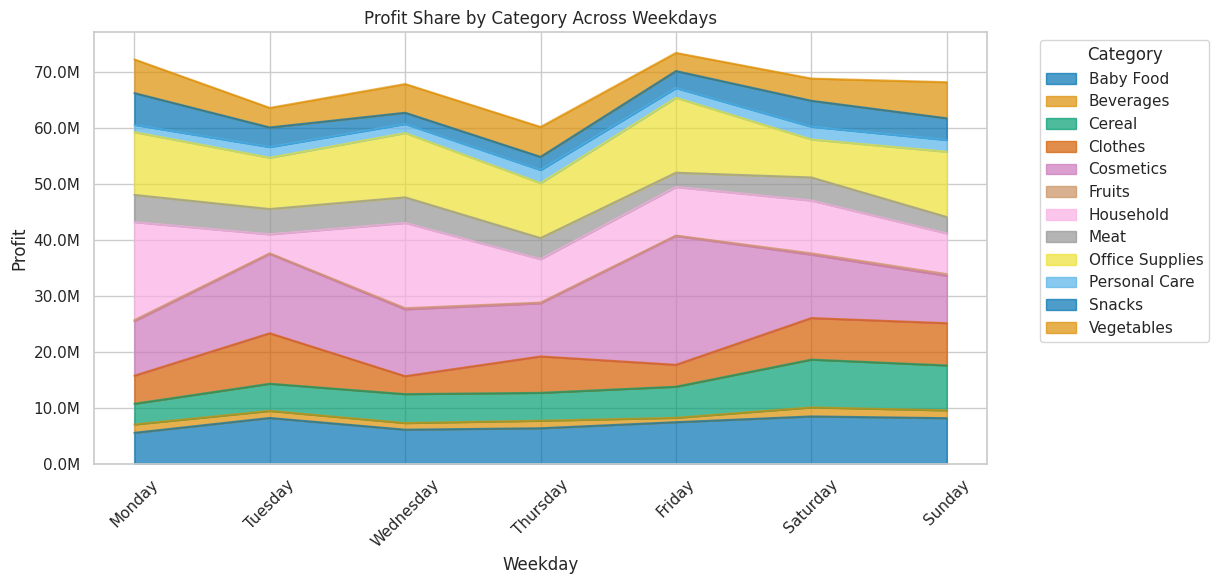

In [ ]:
def millions(x, pos):
    return f'{x*1e-6:,.1f}M'

colors = sns.color_palette("colorblind", n_colors=pivot_weekdays.shape[1])
ax = plt.gca()
pivot_weekdays.plot.area(figsize=(12,6), alpha=0.7, color=colors, ax=ax)
plt.title("Profit Share by Category Across Weekdays")
plt.ylabel("Profit")
plt.xlabel("Weekday")
plt.xticks(rotation=45)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
ax.yaxis.set_major_formatter(FuncFormatter(millions))
plt.show()

Yes, some products show weekly seasonality.


*   Cereal, Clothes, and Baby Food show a clear increase in sales on weekends (Saturday–Sunday).

*   Cosmetics peak on Friday, followed by a decline over the weekend.


*   Household and Office Supplies perform better on weekdays and are less stable on weekends.
*   Fruits gradually increase toward Sunday, but overall volumes are relatively low.


## Sales by Category
The business is currently driven more by scale than efficiency.
To improve performance, focus on scaling high-margin categories like Cosmetics and optimizing costs or pricing in high-volume but low-profit categories.

## Sales by Countries
*   Study the strategies of San Marino and Andorra to scale them to other markets.
*   Reduce operational costs in Ukraine and Andorra without sacrificing volume.
*   Develop marketing campaigns for countries with low sales volume.
*   Keep track of countries with high costs to prevent a decline in profitability.
## Sales by Regions
The ratio of revenue, costs, and profit shows that Europe efficiently manages expenses, achieving high net profit, whereas Asia may need to review its costs or sales strategy.
## Sales Channels
Both channels contribute significantly. The business should support them in parallel rather than focusing on a single channel.
## Delivery Time by Categories
Delivery is slow exactly in the most profitable categories (Cosmetics, Office Supplies, Baby Food), which creates unnecessary risk and delays revenue. Improving logistics in these categories should be a clear priority.
## Delivery Time by Countries
Delivery times are very inconsistent between countries: some orders arrive extremely fast, others take up to 50 days.
Countries like Hungary and Slovakia have particularly long deliveries (up to 50 days), signaling a need to review and improve logistics in these markets.
Looking only at the Min and Max values, it’s easy to see differences in logistics efficiency between countries.
## Delivery Time by Regions
Europe delivers slightly faster than Asia, but the difference is too small to be a real competitive advantage. The key issue is extreme delivery delays (up to 50 days) in both regions, which inflate averages and point to serious logistics inefficiencies that need to be fixed.
## Profit of Each Order vs Delivery Days
*   Profit doesn’t depend on how long delivery takes.
*   Fast orders don’t necessarily bring in more money, and slow orders don’t necessarily bring in less.
 So the company can focus on improving delivery for customer convenience without worrying that it will strongly affect profit.
## Sales Dynamics by Year and Month
*   Focus on selling a mix of products so your business doesn’t rely only on cosmetics, and run promotions before slow months like August. Also, keep enough stock and a small cash reserve for risky periods.
*   The main priority should be to smooth out fluctuations and build a steady, recurring revenue stream.
*   Europe is the main profit driver, but it is unstable: efforts should focus on stabilizing sales and forecasting seasonal trends.
Asia is a potentially promising market, but currently has limited presence and low revenues. Expansion into new countries or strengthening existing markets could be considered.







## Sales by Day of the Week
This is not annual seasonality, but a clear weekly behavioral pattern that can be used for planning promotions, inventory, and delivery capacity.